# Preprocessing — chuẩn hoá dữ liệu Uber NYC cho DBSCAN

Notebook này **không chứa logic preprocessing** — tất cả nằm trong `src/preprocess.py`.
Mục đích của notebook là minh bạch **từng bước xử lý**: dữ liệu thô → dữ liệu sẵn sàng chạy clustering, kèm số liệu đếm và kiểm chứng.

> Notebook clustering sau sẽ `import` lại đúng module này, không copy-paste gì cả.

## Trình tự xử lý

```
data/raw/*.csv (6 tháng, 4.53M chuyến)
        │  1. load_raw         đổi tên cột, parse thời gian, dtype float64
        │  2. add_time_features  hour, dow, date, is_peak...
        │  3. clean_coordinates loại toạ độ lỗi (thiếu / (0,0) / ngoài NYC)
        │  4. to_metric        chiếu sang toạ độ phẳng ĐƠN VỊ MÉT + kiểm chứng
        ▼
  5. filter_window    cắt khung giờ × ngày trong tuần × vùng
        │  6. sample_points  lấy mẫu ngẫu nhiên có seed cố định
        ▼
data/processed/<ca>.csv  +  outputs/preprocess_report.json
```

## 4 nguyên tắc bắt buộc

| Nguyên tắc | Vì sao |
|---|---|
| **Không z-score lat/lon** | Chuẩn hoá phá vỡ ranh giới không gian, cụm không còn bám đường phố |
| **Tính mọi khoảng cách trong hệ phẳng đơn vị mét** | Euclid trên độ là sai (1° lon dài hơn 1° lat ở NYC ~1.3 lần) |
| **Cắt khung giờ × ngày** | Vận hành thực tế khác nhau giữa 8h sáng và 6h tối, gộp cả ngày sẽ trộn hai hiện tượng |
| **Chốt tham số bằng k-distance** | `eps` và `MinPts` phải suy ra từ dữ liệu, không chọn tùy ý |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shapely

# jupyter chay voi cwd = thu muc notebook, nen phai them thu muc goc vao sys.path
ROOT = Path.cwd()
while not (ROOT / "src" / "preprocess.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src" / "preprocess.py").exists():
    raise FileNotFoundError("Khong tim thay src/preprocess.py")
sys.path.insert(0, str(ROOT / "src"))  # module nam trong thu muc src/

import preprocess as pp

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 7)

DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

print("src/preprocess.py:", pp.__file__)
print("Cac kich ban:", sorted(pp.SCENARIOS))

src/preprocess.py: /Users/hongphuc/workspace/CS313/Density-based Method/src/preprocess.py
Cac kich ban: ['ca_diem_t7_manhattan', 'ca_diem_t7_toan_bo', 'ca_sang_t2_manhattan', 'dem_thu7_manhattan']


---

## 1. Đọc dữ liệu + lọc toạ độ lỗi (bước dùng chung)

`prepare_raw` gộp 3 bước đầu và chỉ chạy **một lần** cho mọi kịch bản.

In [2]:
clean, shared_report = pp.prepare_raw(DATA_RAW)

shared_report

  doc apr14.csv       564,516 dong


  doc aug14.csv       829,275 dong


  doc jul14.csv       796,121 dong


  doc jun14.csv       663,844 dong


  doc may14.csv       652,435 dong


  doc sep14.csv     1,028,136 dong


  loc toa do (polygon_5_borough_va_EWR): 4,534,327 -> 4,449,041  (loai 85,286 ngoai vung)


{'raw': {'dong': 4534327, 'files': ['*14.csv']},
 'toi_buoc_loc_toa_do': {'vao': 4534327,
  'ra': 4449041,
  'thieu_toa_do': 0,
  'toa_do_0_0': 0,
  'ngoai_bien_gioi': 31910,
  'ngoai_vung_bo_anh': 85286,
  'bi_loai_tong': 85286,
  'quy_tac': 'polygon_5_borough_va_EWR'}}

In [3]:
qc = shared_report["toi_buoc_loc_toa_do"]

qc_tbl = pd.DataFrame(
    [
        {"buoc": "vao", "so_dong": qc["vao"]},
        {"buoc": "- thieu toa do", "so_dong": -qc["thieu_toa_do"]},
        {"buoc": "- toa do (0, 0)", "so_dong": -qc["toa_do_0_0"]},
        {"buoc": "- ngoai vung bo anh", "so_dong": -qc["ngoai_vung_bo_anh"]},
        {"buoc": "ra", "so_dong": qc["ra"]},
    ]
)
qc_tbl["ty_le_so_vao_pct"] = (qc_tbl["so_dong"] / qc["vao"] * 100).round(3)
print(qc_tbl)
print()
print(f"Quy tac loc: {qc['quy_tac']}")
print(f"Loai {qc['bi_loai_tong']:,} dong ({qc['bi_loai_tong'] / qc['vao'] * 100:.3f}%)")
print()
print(f"Chi so QC: {qc['ngoai_bien_gioi']:,} diem nam ngoai bbox — con lai nam trong bbox")
print("  nhung ngoai ranh gioi hanh chinh. Xem muc 1b de hieu vi sao loai nhieu hon.")

                  buoc  so_dong  ty_le_so_vao_pct
0                  vao  4534327           100.000
1       - thieu toa do        0             0.000
2      - toa do (0, 0)        0             0.000
3  - ngoai vung bo anh   -85286            -1.881
4                   ra  4449041            98.119

Quy tac loc: polygon_5_borough_va_EWR
Loai 85,286 dong (1.881%)

Chi so QC: 31,910 diem nam ngoai bbox — con lai nam trong bbox
  nhung ngoai ranh gioi hanh chinh. Xem muc 1b de hieu vi sao loai nhieu hon.


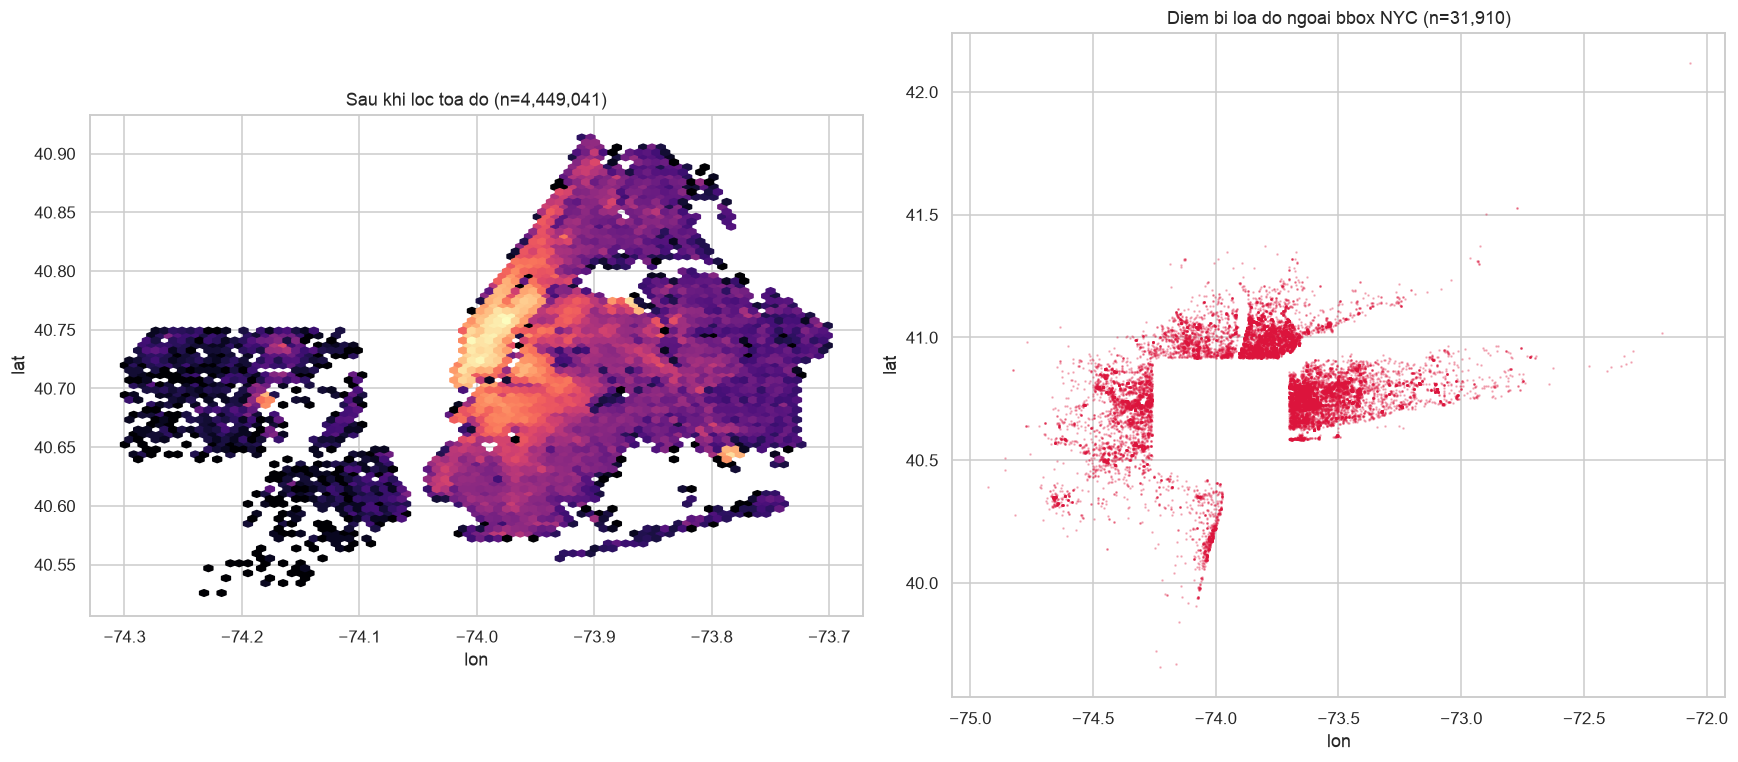

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].hexbin(clean["lon"], clean["lat"], gridsize=80, cmap="magma", mincnt=1, bins="log")
axes[0].set_title(f"Sau khi loc toa do (n={len(clean):,})")

# Ve lai phan bi gioi cua thanh pho de thay vung bi loa nam o dau
raw_spot = pd.concat(
    [
        pd.read_csv(p, usecols=["Lat", "Lon"]) for p in sorted(DATA_RAW.glob("*14.csv"))
    ],
    ignore_index=True,
)
bad = raw_spot[
    ~(
        raw_spot["Lat"].between(*[pp.NYC_BBOX[0], pp.NYC_BBOX[2]])
        & raw_spot["Lon"].between(*[pp.NYC_BBOX[1], pp.NYC_BBOX[3]])
    )
]
axes[1].scatter(bad["Lon"], bad["Lat"], s=0.4, alpha=0.3, color="crimson")
axes[1].set_title(f"Diem bi loa do ngoai bbox NYC (n={len(bad):,})")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

plt.tight_layout()
plt.savefig(OUT / "prep_01_cleaning.png", bbox_inches="tight")
plt.show()

---

## 1b. Quy tắc vùng hợp lệ: polygon 5 borough + ngoại lệ EWR

Bước lọc trên dùng **bounding box** — hình chữ nhật bao quanh thành phố. Bản chất nó vô nghĩa hành chính: giữ lại điểm ở giữa sông Hudson và loại bỏ điểm ở rìa thành phố.

Bước này thay bằng **ranh giới hành chính thật**: polygon 5 borough của NYC, cộng thêm **hộp 5 km quanh sân bay EWR** (Newark Liberty) — vì EWR nằm ở New Jersey nên không thuộc borough nào, nhưng lại là sân bay đón khách lớn (36.003 chuyến).

**Hai khái niệm dễ nhầm — phân biệt rõ:**

| Khái niệm | Ý nghĩa | Nơi dùng |
|---|---|---|
| `RegionMask.valid_region` | Vùng hợp lệ để **kiểm tra** điểm đón có hợp lệ không | `clean_coordinates` — lọc |
| `region` trong config | Vùng **phân tích** — nơi tìm hotspot | `filter_window` — cắt |

Vì vậy kịch bản `ca_diem_t7_toan_bo` có `region="nyc"` (đúng 5 borough, **không** gồm EWR): cần cùng một phạm vi cho cả 5 quận thì mới so sánh mật độ được. Muốn đưa EWR vào một kịch bản riêng thì dùng `region="valid"`.


In [5]:
# Quy tac vung hop le: 5 borough + EWR, doc tu src/preprocess.py
mask = pp.RegionMask(DATA_RAW)
boroughs = mask.boroughs()
print("Quan co trong polygon:", sorted(boroughs))
print(f"Tong so vong: {sum(len(g.geoms) if g.geom_type=='MultiPolygon' else 1 for g in boroughs.values())}")
print(f"Hop EWR (lon_min,lat_min,lon_max,lat_max) = {pp.EWR_BOX}")

Quan co trong polygon: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
Tong so vong: 94
Hop EWR (lon_min,lat_min,lon_max,lat_max) = (-74.3, 40.64, -74.1, 40.75)


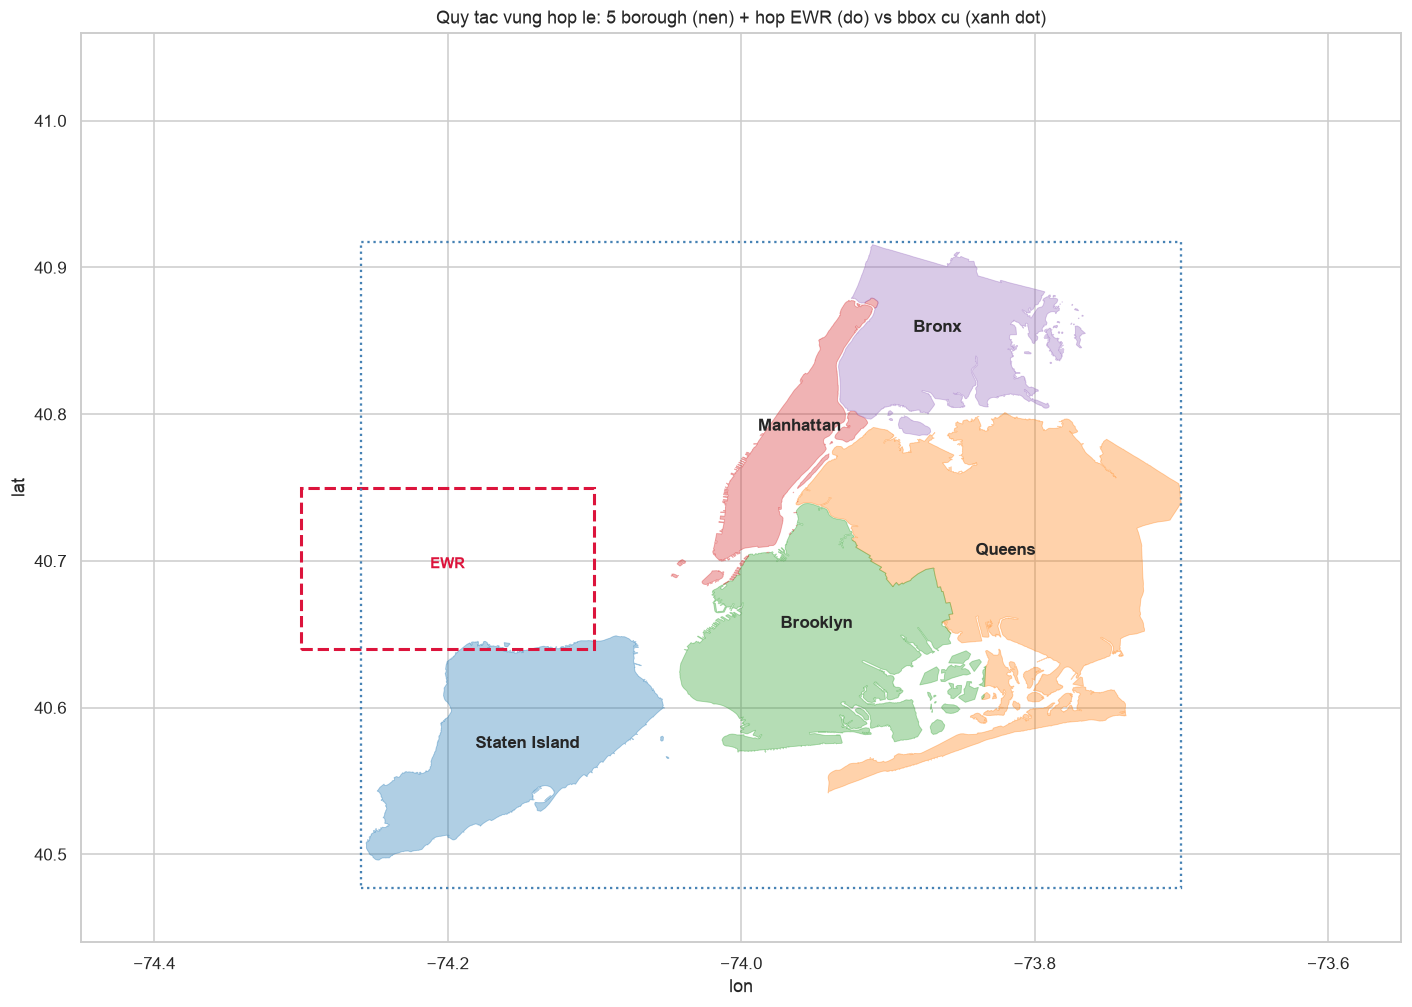

In [6]:
fig, ax = plt.subplots(figsize=(13, 12))

# 1. Hop tat ca 5 quan: mau nen nhat
for name, geom in boroughs.items():
    polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, alpha=0.35, edgecolor="black", linewidth=0.6,
                color=plt.cm.tab10(list(boroughs).index(name) % 10))
    xs, ys = geom.representative_point().x, geom.representative_point().y
    ax.annotate(name, (xs, ys), ha="center", fontsize=11, weight="bold")

# 2. Hop EWR: vach do, mau khac
lon_min, lat_min, lon_max, lat_max = pp.EWR_BOX
ax.add_patch(plt.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                           fill=False, edgecolor="crimson", linewidth=2, linestyle="--"))
ax.annotate("EWR", ((lon_min + lon_max) / 2, (lat_min + lat_max) / 2),
            ha="center", color="crimson", fontsize=10, weight="bold")

# 3. Bounding box cu (chi so QC, khong con la quy tac loc)
lat_min_b, lon_min_b, lat_max_b, lon_max_b = pp.NYC_BBOX
ax.add_patch(plt.Rectangle((lon_min_b, lat_min_b), lon_max_b - lon_min_b, lat_max_b - lat_min_b,
                           fill=False, edgecolor="steelblue", linewidth=1.5, linestyle=":"))

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-74.45, -73.55)
ax.set_ylim(40.44, 41.06)
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.set_title("Quy tac vung hop le: 5 borough (nen) + hop EWR (do) vs bbox cu (xanh dot)")
plt.tight_layout()
plt.savefig(OUT / "prep_06_region_rule.png", bbox_inches="tight")
plt.show()

In [7]:
# So sanh 3 quy tac tren TOAN BO 4.53M diem (dung raw, chua cat khung gio)
raw_all = pp.load_raw(DATA_RAW)
lat_a, lon_a = raw_all["lat"].to_numpy(), raw_all["lon"].to_numpy()

bb = (
    (lat_a > pp.NYC_BBOX[0]) & (lat_a <= pp.NYC_BBOX[2])
    & (lon_a > pp.NYC_BBOX[1]) & (lon_a <= pp.NYC_BBOX[3])
)
poly_only = shapely.contains_xy(mask.all_boroughs, lon_a, lat_a)
poly_ewr = mask.inside(lat_a, lon_a)

cmp = pd.DataFrame(
    [
        {"quy tac": "bbox (cu)", "giu lai": int(bb.sum())},
        {"quy tac": "5 borough polygon", "giu lai": int(poly_only.sum())},
        {"quy tac": "polygon + EWR (moi)", "giu lai": int(poly_ewr.sum())},
    ]
)
cmp["so voi moi"] = cmp["giu lai"] - int(poly_ewr.sum())
print(cmp.to_string(index=False))

# Quan hua chay giua 3 quy tac:
#   - polygon co phai tap con cua bbox khong? (co diem nao trong polygon ma ngoai bbox?)
#   - polygon loai them bao nhiu diem ma bbox van giu?
only_poly = int((poly_ewr & ~bb).sum())
print(f"Diem chi vung hop le giu, bbox loai: {only_poly:,}")
print(f"Diem vung hop le loai, bbox giu      : {int((bb & ~poly_ewr).sum()):,}")
print()

# 451 diem la phan hop EWR vuot bien lon cua bbox. Kiem chung bang cach tach
# xem co diem nao thuoc borough that (hay thi quan he tap con bi sai).
if only_poly:
    la, lo = lat_a[poly_ewr & ~bb], lon_a[poly_ewr & ~bb]
    ewr = shapely.contains_xy(shapely.geometry.box(*pp.EWR_BOX), lo, la)
    n_real = int((~ewr).sum())
    print(f"Trong {only_poly:,} diem do:")
    print(f"  thuoc hop EWR (vuot bien lon bbox): {int(ewr.sum()):,}")
    print(f"  thuoc borough that bi sai          : {n_real:,}")
    print()
    if n_real == 0:
        print("=> 5 borough polygon VAN LA TAP CON cua bbox (khong quan nao vuot bien lon).")
        print("   451 diem la phan hop EWR — dung roi, vi EWR nam o New Jersey.")
    else:
        print(f"=> CANH BAO: {n_real:,} diem thuoc borough thuc su ma van nam ngoai bbox.")
        print("   Kiem tra lai bbox NYC_BBOX co bao phu toan bo 5 quan hay khong.")
else:
    print("=> Vung hop le la TAP CON cua bbox: doi quy tac sang polygon chi LOAI them,")
    print("   khong bao gio giu them diem nao.")

# Diem bi loai: phan bo theo cụm de biet dang bo cai
extra = bb & ~poly_only
if extra.sum():
    from sklearn.cluster import DBSCAN

    la, lo = lat_a[extra], lon_a[extra]
    R = pp.EARTH_R
    ar, orad, a0 = np.radians(la), np.radians(lo), np.radians(40.74)
    xy = np.column_stack([
        R * np.cos(ar) * np.sin(orad),
        R * (np.cos(a0) * np.sin(ar) - np.sin(a0) * np.cos(ar) * np.cos(orad)),
    ])
    lab = DBSCAN(eps=1500, min_samples=400).fit_predict(xy)
    rows = []
    for c in sorted(set(lab) - {-1}):
        s = lab == c
        rows.append({
            "cum": int(c),
            "n": int(s.sum()),
            "lat": round(float(la[s].mean()), 4),
            "lon": round(float(lo[s].mean()), 4),
            "ban_kinh_km": round(float(np.hypot(xy[s][:, 0] - xy[s][:, 0].mean(),
                                                xy[s][:, 1] - xy[s][:, 1].mean()).mean() / 1000), 2),
        })
    print()
    print("Cac cum bi loai khi dung polygon:")
    print(pd.DataFrame(rows).to_string(index=False))
    print(f"noise: {int((lab == -1).sum()):,} diem rai rac")

  doc apr14.csv       564,516 dong


  doc aug14.csv       829,275 dong


  doc jul14.csv       796,121 dong


  doc jun14.csv       663,844 dong


  doc may14.csv       652,435 dong


  doc sep14.csv     1,028,136 dong


            quy tac  giu lai  so voi moi
          bbox (cu)  4502415       53374
  5 borough polygon  4411894      -37147
polygon + EWR (moi)  4449041           0
Diem chi vung hop le giu, bbox loai: 451
Diem vung hop le loai, bbox giu      : 53,825

Trong 451 diem do:
  thuoc hop EWR (vuot bien lon bbox): 451
  thuoc borough that bi sai          : 0

=> 5 borough polygon VAN LA TAP CON cua bbox (khong quan nao vuot bien lon).
   451 diem la phan hop EWR — dung roi, vi EWR nam o New Jersey.



Cac cum bi loai khi dung polygon:
 cum     n     lat      lon  ban_kinh_km
   0 45772 40.7495 -74.0361         2.79
   1 36003 40.6956 -74.1788         0.72
   2   759 40.7089 -73.7153         1.13
   3  1190 40.7840 -73.7208         1.17
   4   481 40.8166 -74.2163         0.92
   5   767 40.6253 -73.7258         1.20
   6   931 40.9025 -73.7951         1.32
noise: 4,618 diem rai rac


### Phân bố theo quận — và tại sao không được xếp hạng theo tổng số chuyến


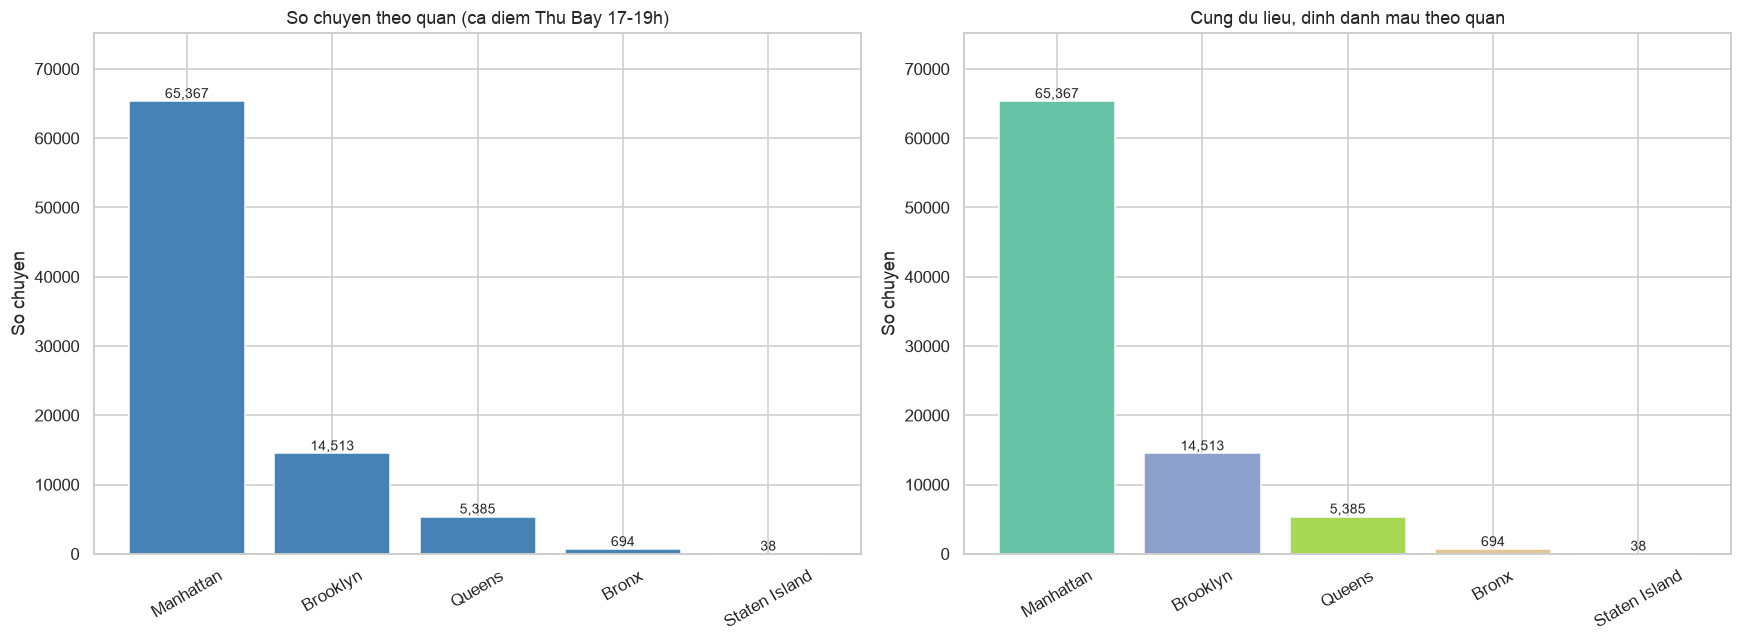

               chuyen  share_pct
quan                            
Manhattan       65367      76.01
Brooklyn        14513      16.88
Queens           5385       6.26
Bronx             694       0.81
Staten Island      38       0.04

Luu y khi xep hang hotspot:
  Staten Island chi 38 chuyen, Manhattan 65,367 — gap 1720 lan
  -> mat do khac nhau cuc manh giua cac quan, nen phai tinh CHUYEN/GIO
     (hoac chuyen/km^2) de xep hang, khong xep hang theo tong so chuyen.


In [8]:
# Phan bo chuyen theo quan. Hai bang o cung du lieu — bang trai de doc
# nhanh, bang phai de so sanh mau (seu cam hon).
df_b = pp.load_processed(DATA_PROC / "ca_diem_t7_toan_bo.csv")
counts = df_b["borough"].value_counts().rename_axis("quan").to_frame("chuyen")
counts["share_pct"] = (counts["chuyen"] / counts["chuyen"].sum() * 100).round(2)

colors = dict(zip(counts.index, plt.cm.Set2(np.linspace(0, 1, len(counts)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bang trai: mot mau chung, de doc nhanh
axes[0].bar(counts.index, counts["chuyen"], color="steelblue")
for i, (name, row) in enumerate(counts.iterrows()):
    axes[0].annotate(f"{int(row['chuyen']):,}", (i, row["chuyen"]),
                     ha="center", va="bottom", fontsize=9)
axes[0].set_title("So chuyen theo quan (ca diem Thu Bay 17-19h)")
axes[0].set_ylabel("So chuyen")
axes[0].set_ylim(0, counts["chuyen"].max() * 1.15)
plt.setp(axes[0].get_xticklabels(), rotation=30)

# Bang phai: mau theo quan, cung thu tu -> so sanh truc quan
axes[1].bar(counts.index, counts["chuyen"], color=[colors[q] for q in counts.index])
for i, (name, row) in enumerate(counts.iterrows()):
    axes[1].annotate(f"{int(row['chuyen']):,}", (i, row["chuyen"]),
                     ha="center", va="bottom", fontsize=9)
axes[1].set_title("Cung du lieu, dinh danh mau theo quan")
axes[1].set_ylabel("So chuyen")
axes[1].set_ylim(0, counts["chuyen"].max() * 1.15)
plt.setp(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(OUT / "prep_07_by_borough.png", bbox_inches="tight")
plt.show()

print(counts.to_string())
print()
print("Luu y khi xep hang hotspot:")
si = int(counts["chuyen"].get("Staten Island", 0))
mn = int(counts["chuyen"].get("Manhattan", 0))
print(f"  Staten Island chi {si:,} chuyen, Manhattan {mn:,} — gap {mn / max(si, 1):.0f} lan")
print("  -> mat do khac nhau cuc manh giua cac quan, nen phai tinh CHUYEN/GIO")
print("     (hoac chuyen/km^2) de xep hang, khong xep hang theo tong so chuyen.")

> **Bài học:** toạ độ sai không nằm rải rác ngẫu nhiên mênh mông — chúng tụ lại thành các cụm rõ rệt.
> Nếu không lọc, DBSCAN sẽ phát hiện "hotspot" ở New Jersey hoặc ngoài biển, và mọi phân tích phía sau đều vô nghĩa.

---

## 2. Chiếu sang toạ độ phẳng đơn vị mét

Đây là bước quyết định `eps` có nghĩa hay không. Đo thử cả 3 phương án:

In [9]:
lat, lon = clean["lat"].to_numpy(), clean["lon"].to_numpy()
lat0, lon0 = float(lat.mean()), float(lon.mean())
R = pp.EARTH_R


def eq_cos_lat0():
    return np.column_stack(
        [R * np.radians(lon - lon0) * np.cos(np.radians(lat0)), R * np.radians(lat - lat0)]
    )


def eq_cos_lat():
    return np.column_stack(
        [R * np.radians(lon - lon0) * np.cos(np.radians(lat)), R * np.radians(lat - lat0)]
    )


rng = np.random.default_rng(42)
n = len(clean)
i, j = rng.integers(0, n, 20000), rng.integers(0, n, 20000)
d_true = pp.haversine_m(lat[i], lon[i], lat[j], lon[j])

rows = []
for name, fn in [
    ("equirectangular cos(lat0)", eq_cos_lat0),
    ("equirectangular cos(lat)", eq_cos_lat),
    ("azimuthal equidistant", lambda: pp.to_metric(lat, lon, lat0, lon0)),
]:
    xy = fn()
    d = np.hypot(xy[i, 0] - xy[j, 0], xy[i, 1] - xy[j, 1])
    far = d_true >= 100  # thu do cua bai la 100 m
    rel = np.abs(d[far] - d_true[far]) / d_true[far]
    rows.append(
        {
            "phuong_phap": name,
            "sai_so_tb_pct": rel.mean() * 100,
            "sai_so_p99_pct": np.percentile(rel, 99) * 100,
            "sai_so_max_pct": rel.max() * 100,
        }
    )

pd.DataFrame(rows).round(6)

,phuong_phap,sai_so_tb_pct,sai_so_p99_pct,sai_so_max_pct
0,equirectangular cos(lat0),0.012053,0.075621,0.165462
1,equirectangular cos(lat),0.008330,0.054849,0.112633
2,azimuthal equidistant,0.000002,0.000019,0.000119


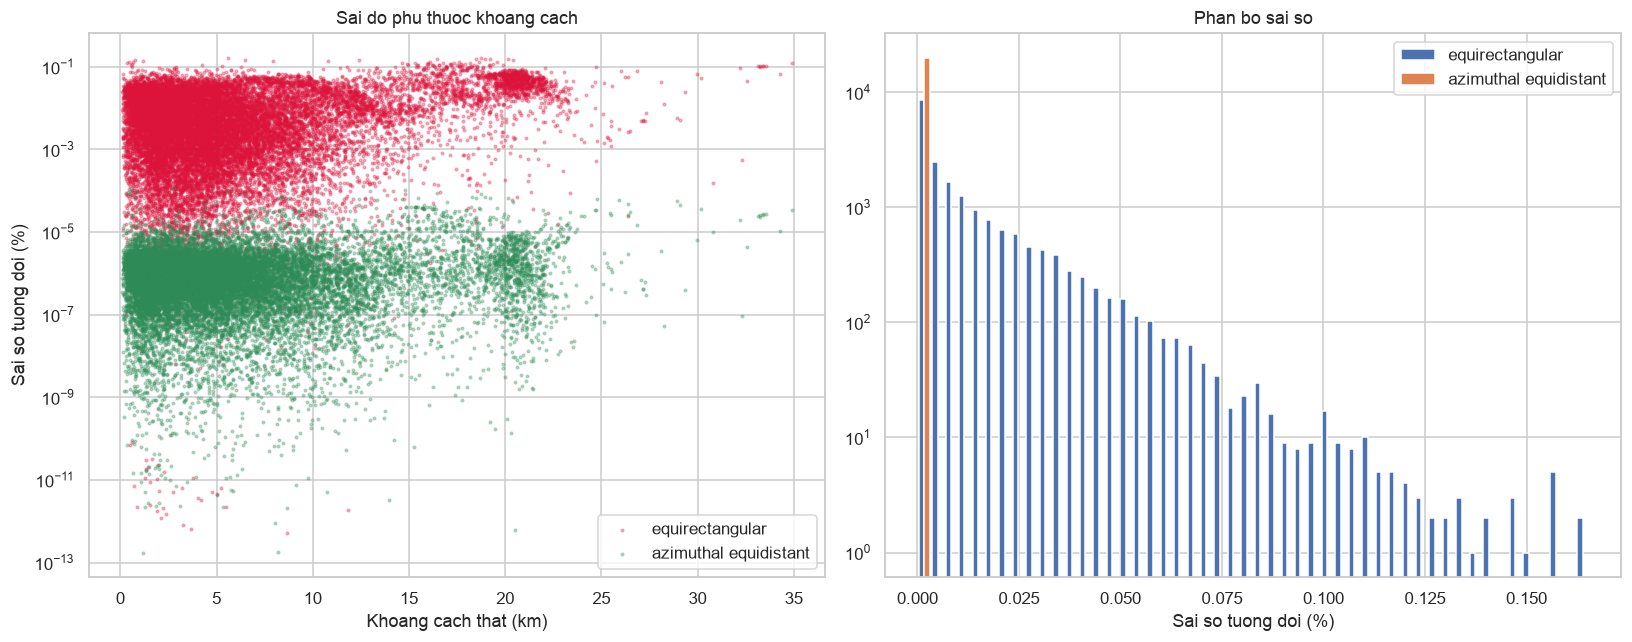

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

xy_eq = eq_cos_lat0()
xy_ae = pp.to_metric(lat, lon, lat0, lon0)
far = d_true >= 100

for xy, name, color in [(xy_eq, "equirectangular", "crimson"), (xy_ae, "azimuthal equidistant", "seagreen")]:
    d = np.hypot(xy[i, 0] - xy[j, 0], xy[i, 1] - xy[j, 1])
    rel = np.abs(d[far] - d_true[far]) / d_true[far] * 100
    axes[0].scatter(d_true[far] / 1000, rel, s=3, alpha=0.3, label=name, color=color)

axes[0].set_yscale("log")
axes[0].set_xlabel("Khoang cach that (km)")
axes[0].set_ylabel("Sai so tuong doi (%)")
axes[0].set_title("Sai do phu thuoc khoang cach")
axes[0].legend()

axes[1].hist(
    [
        np.abs(
            np.hypot(xy_eq[i, 0] - xy_eq[j, 0], xy_eq[i, 1] - xy_eq[j, 1])[far] - d_true[far]
        )
        / d_true[far]
        * 100,
        np.abs(
            np.hypot(xy_ae[i, 0] - xy_ae[j, 0], xy_ae[i, 1] - xy_ae[j, 1])[far] - d_true[far]
        )
        / d_true[far]
        * 100,
    ],
    bins=50,
    log=True,
    label=["equirectangular", "azimuthal equidistant"],
)
axes[1].set_xlabel("Sai so tuong doi (%)")
axes[1].set_title("Phan bo sai so")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / "prep_02_projection.png", bbox_inches="tight")
plt.show()

Kết luận: chỉ **azimuthal equidistant** đạt sai số < 0.001% trên toàn bộ NYC, nên `eps` đọc được là **mét thật** mà không phải hiệu chỉnh tay.

---

## 3. Cắt khung giờ × ngày × vùng — 4 kịch bản

Dùng `build_all` để cả 4 ca dùng chung dữ liệu đã đọc một lần.

In [11]:
reports: dict = {}
results = pp.build_all(list(pp.SCENARIOS.values()), DATA_RAW, report=reports)
print()
print(f"Da xu ly {len(results)} kich ban")

  doc apr14.csv       564,516 dong


  doc aug14.csv       829,275 dong


  doc jul14.csv       796,121 dong


  doc jun14.csv       663,844 dong


  doc may14.csv       652,435 dong


...

  loc toa do (polygon_5_borough_va_EWR): 4,534,327 -> 4,449,041  (loai 85,286 ngoai vung)

=== ca_diem_t7_manhattan: Thu Bay 17:00-19:00 ===


  -> 65,367 diem (manhattan) | Manhattan=65,367

=== ca_diem_t7_toan_bo: Thu Bay 17:00-19:00 ===


  -> 85,997 diem (nyc) | Manhattan=65,367, Brooklyn=14,513, Queens=5,385

=== ca_sang_t2_manhattan: Thu Hai 08:00-10:00 ===


  -> 38,123 diem (manhattan) | Manhattan=38,123

=== dem_thu7_manhattan: Thu Bay 00:00-04:00 ===


  -> 49,752 diem (manhattan) | Manhattan=49,752

Da xu ly 4 kich ban


In [12]:
def flow_table(name: str) -> pd.DataFrame:
    r = reports[name]
    return pd.DataFrame(
        {
            "buoc": ["doc raw", "loc toa do loi", "cat gio/ngay/vung", "lay mau"],
            "vao": [
                0,
                r["toi_buoc_loc_toa_do"]["vao"],
                r["cat_khung_gio_ngay_vung"]["vao"],
                r["lay_mau"]["vao"],
            ],
            "ra": [
                r["raw"]["dong"],
                r["toi_buoc_loc_toa_do"]["ra"],
                r["cat_khung_gio_ngay_vung"]["ra"],
                r["lay_mau"]["ra"],
            ],
        }
    ).assign(
        scenario=name,
        giu_lai=lambda d: (d["ra"] / d["ra"].iloc[0] * 100).round(2),
    )


flow = pd.concat([flow_table(n) for n in reports], ignore_index=True)
flow

,buoc,vao,ra,scenario,giu_lai
0,doc raw,0,4534327,ca_diem_t7_manhattan,100.00
1,loc toa do loi,4534327,4449041,ca_diem_t7_manhattan,98.12
2,cat gio/ngay/vung,4449041,65367,ca_diem_t7_manhattan,1.44
3,lay mau,65367,65367,ca_diem_t7_manhattan,1.44
4,doc raw,0,4534327,ca_diem_t7_toan_bo,100.00
5,loc toa do loi,4534327,4449041,ca_diem_t7_toan_bo,98.12
6,cat gio/ngay/vung,4449041,85997,ca_diem_t7_toan_bo,1.90
7,lay mau,85997,85997,ca_diem_t7_toan_bo,1.90
8,doc raw,0,4534327,ca_sang_t2_manhattan,100.00
9,loc toa do loi,4534327,4449041,ca_sang_t2_manhattan,98.12


In [13]:
DATA_PROC.mkdir(parents=True, exist_ok=True)
for name, res in zip(reports, results):
    path = DATA_PROC / f"{name}.csv"
    res.points.to_csv(path, index=False)
    print(f"  {path.relative_to(ROOT)}  ({len(res.points):,} dong, {path.stat().st_size / 1e6:.1f} MB)")

  data/processed/ca_diem_t7_manhattan.csv  (65,367 dong, 6.7 MB)


  data/processed/ca_diem_t7_toan_bo.csv  (85,997 dong, 8.8 MB)
  data/processed/ca_sang_t2_manhattan.csv  (38,123 dong, 3.9 MB)


  data/processed/dem_thu7_manhattan.csv  (49,752 dong, 5.1 MB)


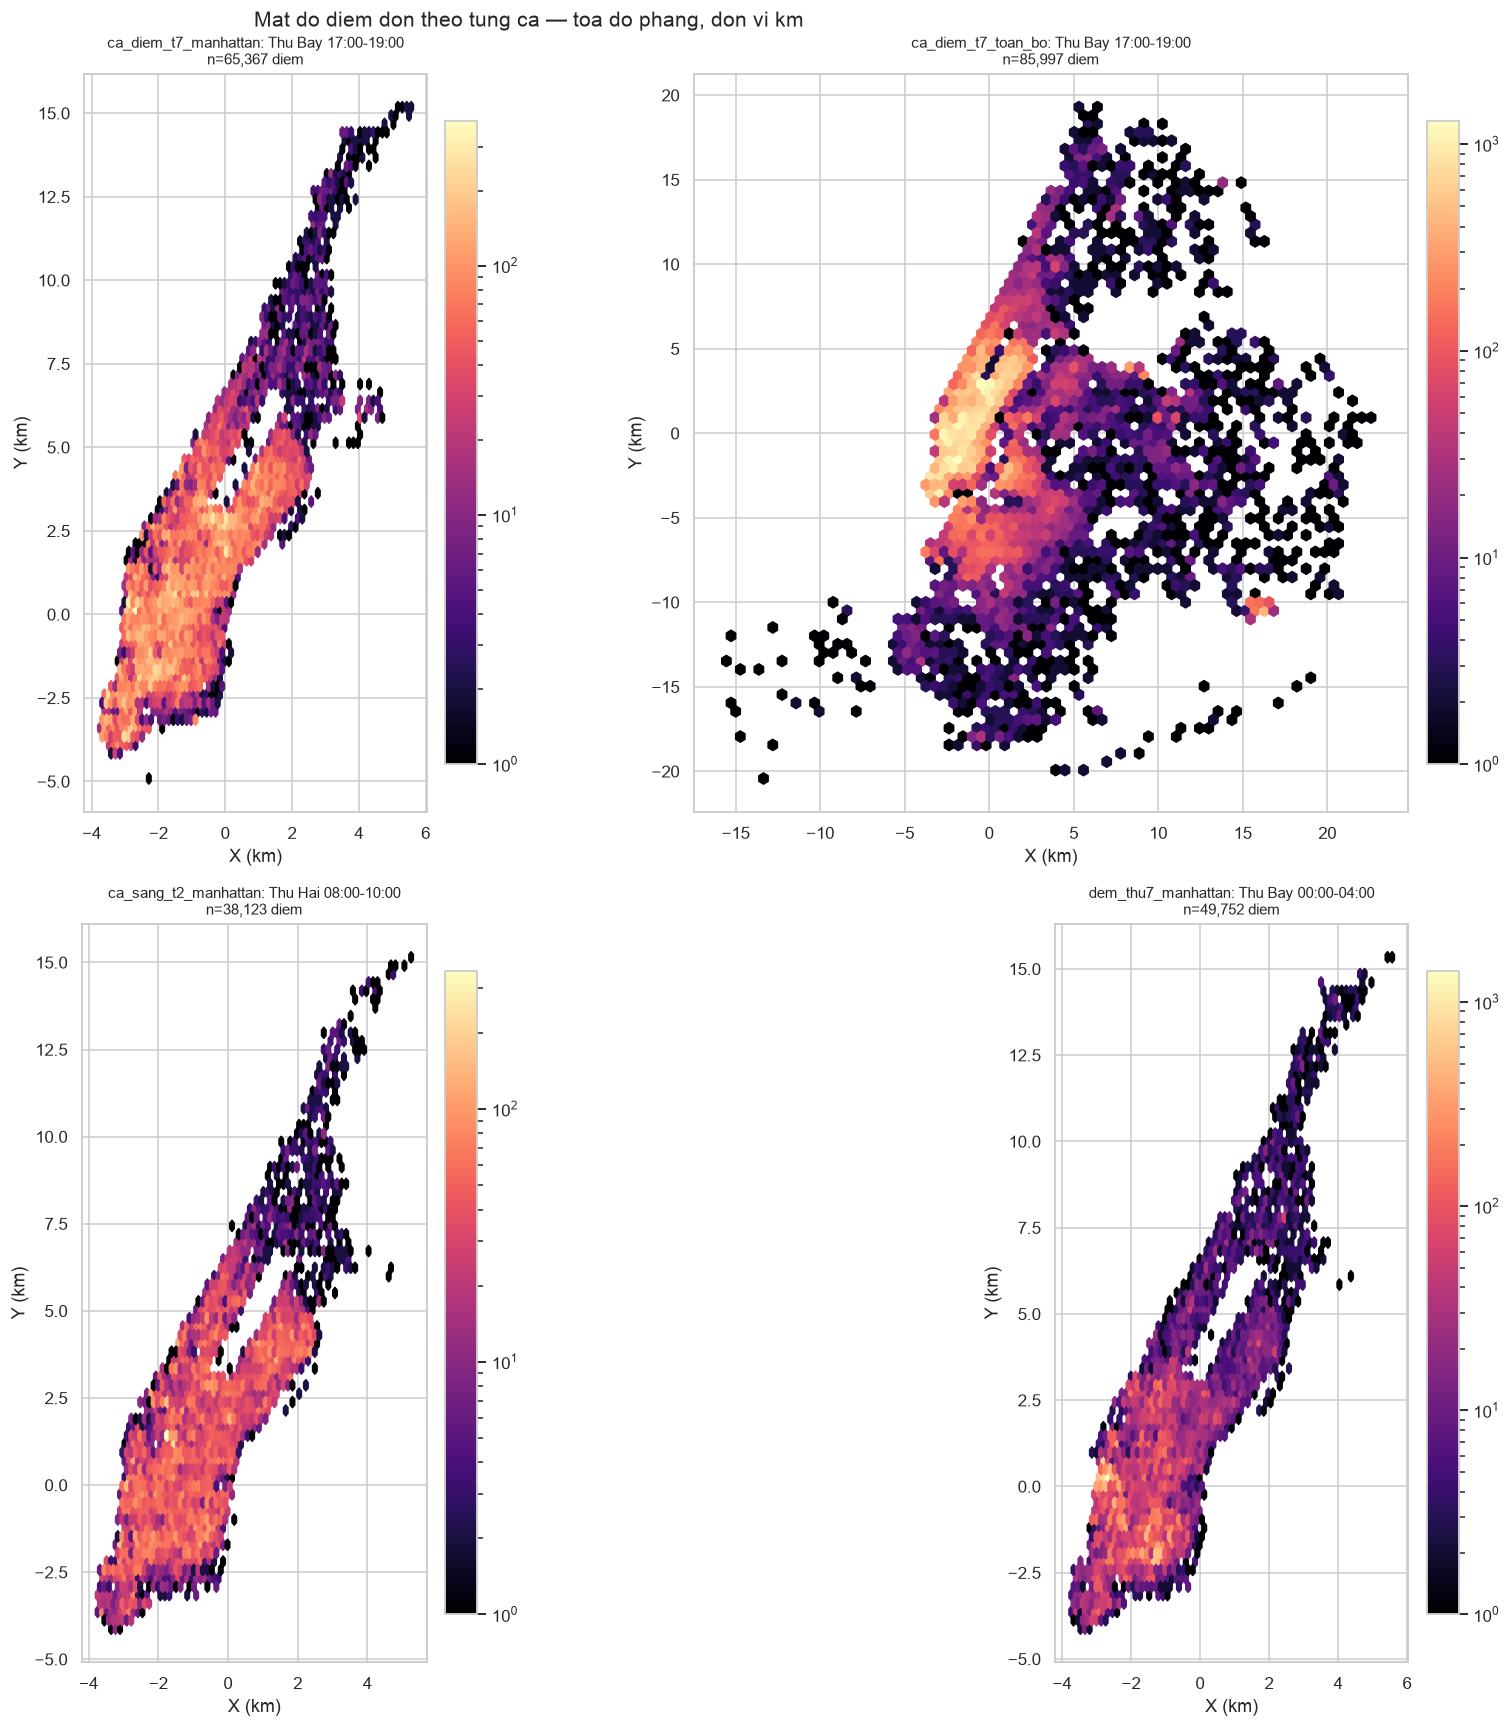

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
for ax, (name, res) in zip(axes.ravel(), zip(reports, results)):
    c = reports[name]["ket_qua"]
    xy = res.coords / 1000
    hb = ax.hexbin(xy[:, 0], xy[:, 1], gridsize=70, cmap="magma", mincnt=1, bins="log")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(pp.SCENARIOS[name].describe() + f"\nn={len(res.points):,} diem", fontsize=10)
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")
    fig.colorbar(hb, ax=ax, fraction=0.035, pad=0.02)

plt.suptitle("Mat do diem don theo tung ca — toa do phang, don vi km", fontsize=14)
plt.tight_layout()
plt.savefig(OUT / "prep_03_scenarios.png", bbox_inches="tight")
plt.show()

---

## 4. Chốt `eps` và `MinPts` cho từng ca bằng k-distance

Đường cong k-distance: với mỗi điểm, sắp xếp khoảng cách tới các lân cận gần nhất rồi vẽ theo thứ tự. Chỗ đường cong **bẻ ngang** (elbow) là ngưỡng mà điểm bắt đầu thuộc về một cụm thật.

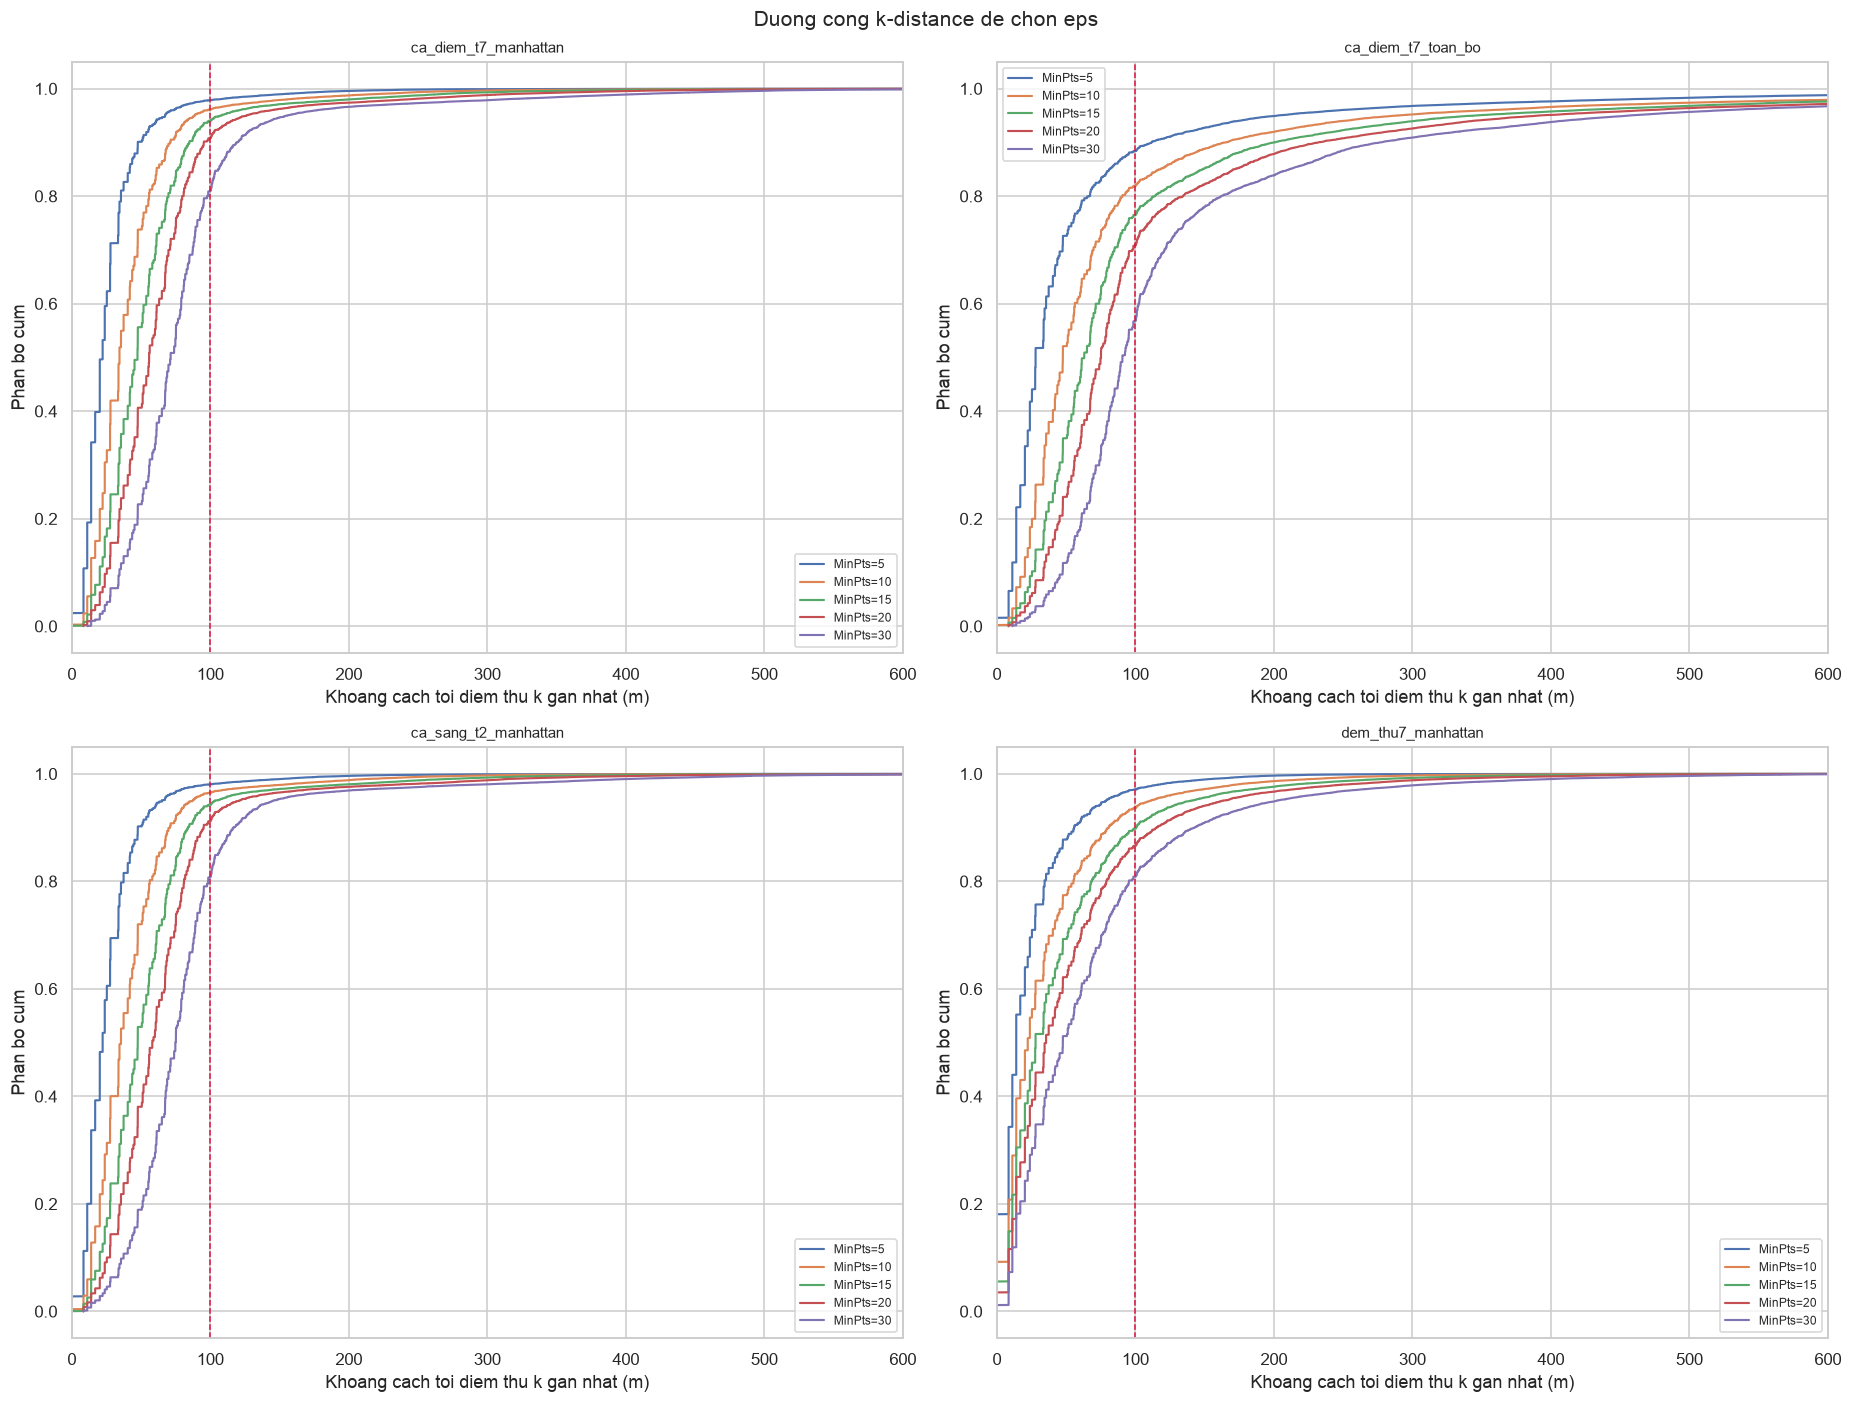

In [15]:
from sklearn.neighbors import NearestNeighbors

K_LIST = [5, 10, 15, 20, 30]
MAX_K = max(K_LIST)
SAMPLE = 40_000

kd = {}
for name, res in zip(reports, results):
    xy = res.coords
    rng = np.random.default_rng(pp.SCENARIOS[name].seed)
    sub = xy if len(xy) <= SAMPLE else xy[rng.choice(len(xy), SAMPLE, replace=False)]
    nn = NearestNeighbors(n_neighbors=MAX_K + 1, n_jobs=-1).fit(sub)
    d, _ = nn.kneighbors(sub)
    kd[name] = np.sort(d[:, 1:], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(17, 13))
for ax, name in zip(axes.ravel(), reports):
    d = kd[name]
    for k in K_LIST:
        col = d[:, k - 1]
        col = col[col < 1500]
        ax.plot(np.sort(col), np.arange(1, len(col) + 1) / len(col), lw=1.4, label=f"MinPts={k}")
    ax.axvline(100, color="crimson", ls="--", lw=1)
    ax.set_xlim(0, 600)
    ax.set_xlabel("Khoang cach toi diem thu k gan nhat (m)")
    ax.set_ylabel("Phan bo cum")
    ax.set_title(pp.SCENARIOS[name].name, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Duong cong k-distance de chon eps", fontsize=14)
plt.tight_layout()
plt.savefig(OUT / "prep_04_kdistance.png", bbox_inches="tight")
plt.show()

In [16]:
rows = []
for name, d in kd.items():
    for eps_m in [50, 75, 100, 150, 200]:
        row = {"scenario": name, "eps_m": eps_m}
        for k in K_LIST:
            row[f"MinPts={k}"] = round((d[:, k - 1] <= eps_m).mean() * 100, 1)
        rows.append(row)

share = pd.DataFrame(rows)
for name in reports:
    print(f"\n{name}")
    print(share[share["scenario"] == name].drop(columns="scenario").to_string(index=False))

print("\nGia tri la % so diem co it nhat k ban trong ban kinh eps")


ca_diem_t7_manhattan
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      90.1       73.8       55.6       40.6       22.7
    75      96.2       91.2       83.5       74.1       53.5
   100      97.8       96.1       94.0       90.7       80.9
   150      98.9       97.9       97.1       96.2       94.6
   200      99.6       98.7       98.0       97.4       96.6

ca_diem_t7_toan_bo
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      72.5       51.9       34.7       23.8       11.6
    75      82.8       72.4       61.3       49.4       31.4
   100      88.2       81.6       76.0       70.1       55.9
   150      92.5       88.5       84.6       81.4       76.8
   200      94.7       91.6       89.4       87.0       82.6

ca_sang_t2_manhattan
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      90.2       72.0       52.9       38.1       18.9
    75      96.6       91.6       82.9       71.9       50.0
   100      98.0     

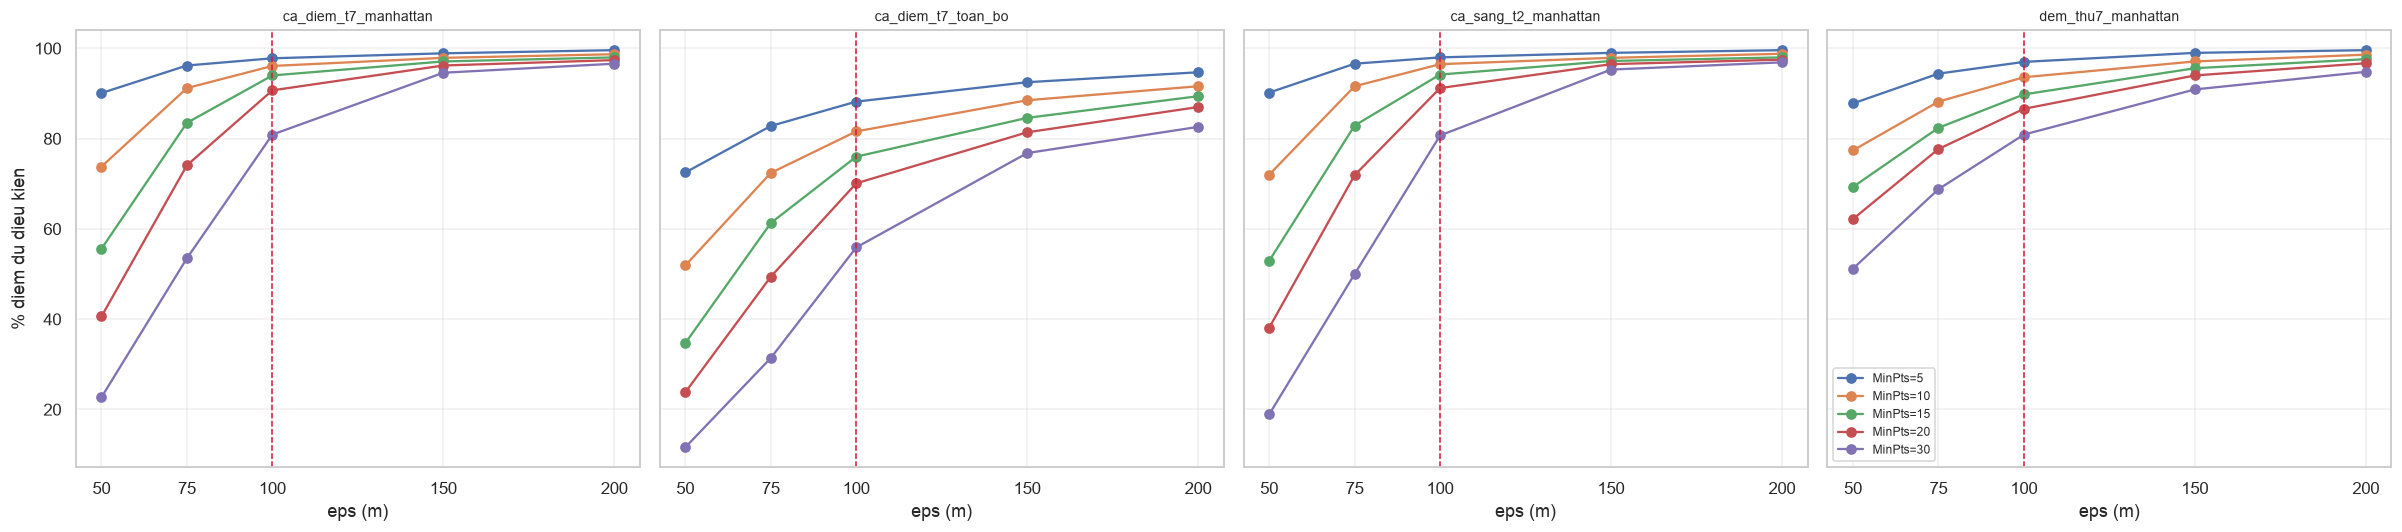

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, name in zip(axes, reports):
    sub = share[share["scenario"] == name]
    for col in [c for c in sub.columns if c.startswith("MinPts")]:
        ax.plot(sub["eps_m"], sub[col], marker="o", label=col)
    ax.axvline(100, color="crimson", ls="--", lw=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("eps (m)")
    ax.set_xticks([50, 75, 100, 150, 200])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("% diem du dieu kien")
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "prep_05_eps_sensitivity.png", bbox_inches="tight")
plt.show()

**Cách đọc bảng:** với `MinPts = 15`, `eps = 100 m`, nếu chỉ ~50–60% số điểm thoả điều kiện thì phần lớn dữ liệu sẽ thành **noise** — đúng tinh thần lọc nhiễu của DBSCAN. Nếu tỷ lệ này là 95% thì `eps` quá lớn, mọi chuyến lẻ cũng bị gộp vào một cụm khổng lồ và bài toán mất ý nghĩa.

---

## 5. Kiểm chứng đầu ra

Các assert ở đây là điều kiện để được chạy clustering. Nếu một cái fail thì dữ liệu đầu ra không đáng tin.

In [18]:
for name, res in zip(reports, results):
    dfp = res.points
    err = reports[name]["projection"]["loi_max_pct"]
    assert dfp["lat"].notna().all() and dfp["lon"].notna().all()
    assert dfp["x_m"].notna().all() and dfp["y_m"].notna().all()
    assert err < 0.001, f"{name}: phieu sai {err}%"
    assert dfp["hour"].between(0, 23).all()
    assert dfp["dow"].between(0, 6).all()
    assert dfp["borough"].notna().all(), f"{name}: thieu cot borough"
    assert "ngoai_vung" not in set(dfp["borough"]), f"{name}: con diem ngoai vung hop le"
    print(
        f"{name:24s} n={len(dfp):>7,}  x=[{dfp['x_m'].min():9.0f},{dfp['x_m'].max():9.0f}]"
        f"  y=[{dfp['y_m'].min():9.0f},{dfp['y_m'].max():9.0f}]  loi={err:.6f}%"
        f"  vung={reports[name]['ket_qua']['vung']}"
    )

print("\nTat ca kich ban vuot qua kiem chung.")

ca_diem_t7_manhattan     n= 65,367  x=[    -3748,     5569]  y=[    -4912,    15183]  loi=0.000024%  vung=manhattan
ca_diem_t7_toan_bo       n= 85,997  x=[   -15546,    22866]  y=[   -20423,    19297]  loi=0.000134%  vung=nyc
ca_sang_t2_manhattan     n= 38,123  x=[    -3740,     5257]  y=[    -4122,    15149]  loi=0.000021%  vung=manhattan
dem_thu7_manhattan       n= 49,752  x=[    -3732,     5568]  y=[    -4122,    15338]  loi=0.000028%  vung=manhattan

Tat ca kich ban vuot qua kiem chung.


In [19]:
import json

for name in reports:
    reports[name]["scenario"] = name

report_path = OUT / "preprocess_report.json"
report_path.write_text(json.dumps(reports, indent=2, ensure_ascii=False))
print("Bao cao QC:", report_path.relative_to(ROOT))
reports

Bao cao QC: outputs/preprocess_report.json


{'ca_diem_t7_manhattan': {'raw': {'dong': 4534327, 'files': ['*14.csv']},
  'toi_buoc_loc_toa_do': {'vao': 4534327,
   'ra': 4449041,
   'thieu_toa_do': 0,
   'toa_do_0_0': 0,
   'ngoai_bien_gioi': 31910,
   'ngoai_vung_bo_anh': 85286,
   'bi_loai_tong': 85286,
   'quy_tac': 'polygon_5_borough_va_EWR'},
  'cat_khung_gio_ngay_vung': {'vao': 4449041, 'ra': 65367},
  'lay_mau': {'vao': 65367, 'ra': 65367, 'n_yeu_cau': None},
  'projection': {'lat0': 40.73847672255661,
   'lon0': -73.97372795874436,
   'loi_max_pct': 2.3564734211039717e-05,
   'loi_p99_pct': 6.968368580435554e-06,
   'n_cap_kiem_chung': 19972},
  'ket_qua': {'n_diem': 65367,
   'n_toa_do_lat_khac_nhau': 1477,
   'khoang_gio': [17, 19],
   'ngay_trong_tuan': [5],
   'vung': 'manhattan',
   'theo_quan': {'Manhattan': 65367}},
  'scenario': 'ca_diem_t7_manhattan'},
 'ca_diem_t7_toan_bo': {'raw': {'dong': 4534327, 'files': ['*14.csv']},
  'toi_buoc_loc_toa_do': {'vao': 4534327,
   'ra': 4449041,
   'thieu_toa_do': 0,
   'toa_d

---

## Quy tắc vùng hợp lệ

Đo trên toàn bộ 4.534.327 chuyến:

| Quy tắc | Giữ lại | Ghi chú |
|---|---|---|
| bbox (cũ) | 4.502.415 | Hình chữ nhật, không có ý nghĩa hành chính |
| 5 borough polygon | 4.411.894 | Loại sạch điểm ngoài khơi |
| **polygon + EWR (đang dùng)** | **4.449.041** | +37.147 điểm sân bay Newark |

Polygon là tập con của bbox: không điểm nào nằm trong polygon mà lại nằm ngoài bbox. Điểm bị loại thêm gồm **45.772 điểm Jersey City/Hoboken** (bờ Hudson, cách Manhattan 2 km qua cầu) và ~21.000 điểm rải rác.

> **Điểm cần bàn trước khi nộp bài:** Jersey City/Hoboken là vùng đông dân làm việc thật. Nếu phạm vi nghiên cứu chỉ là NYC thì loại là đúng. Nếu muốn vùng điều phố liên quận thì cần thêm hành lang NJ vào `RegionMask`.

---

## Kết luận

| Bước | Quyết định đã đưa ra | Căn cứ |
|---|---|---|
| Đọc | `float64` cho toạ độ | `float32` chỉ chính xác ~0.4 m ở NYC, sai số tương đối nhảy lên với cặp điểm gần nhau |
| Parse thời gian | `format="mixed"` | có dòng kèm giây (`:00`), format cứng sẽ crash |
| Quy tắc vùng | polygon 5 borough + EWR | loại đúng 5.5k điểm ngoài khơi; có ý nghĩa hành chính để báo cáo theo quận |
| Chiếu toạ độ | azimuthal equidistant | sai số max 0.0001% vs 0.18% của equirectangular (đo thật ở trên) |
| Cắt khung giờ | theo ca × ngày × vùng | giảm 4.5M → 38–86k điểm, và phản ánh vận hành thật |
| Lấy mẫu | seed cố định 42 | kết quả lặp lại được, không "may mắn" |
| Gắn nhãn | cột `borough` | phân tích hotspot theo quận mà không cần join lại |

### Bước tiếp theo

```python
import preprocess as pp
from sklearn.cluster import DBSCAN

df = pp.load_processed("data/processed/ca_diem_t7_manhattan.csv")
xy = df[["x_m", "y_m"]].to_numpy()          # don vi MET
labels = DBSCAN(eps=100, min_samples=15).fit_predict(xy)
```

1. Chạy DBSCAN với `eps ∈ {50, 100, 200 m}` × `MinPts ∈ {10, 15, 20}`, đo silhouette và tỷ lệ noise
2. Chuyển mỗi cụm thành đa giôn vùng đón
3. Xếp hạng hotspot theo **số chuyến / giờ** (đặc biệt khi so sánh giữa Manhattan và Staten Island)
4. So sánh với K-Means và KDE